### Linear Regression Model
#### Is Population Count a Better Predictor of Food Insecurity Than Urban/Rural Classification?

At the U.S. county level, does 2010 Census population (`Pop2010`) or urban/rural status (`Urban`) better predict the share of the population that is food insecure (`pctFoodInsecure`)?

To answer our research question, we ran an OLS linear regression with `pctFoodInsecure ~ log₁₀(Pop2010) + Urban_prop`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [2]:
DATA_PATH = '../data/MMG_FARA_2019_county.csv'
df = pd.read_csv(DATA_PATH)

KEY_COLS = ['Pop2010', 'Urban', 'n_tracts', 'pctFoodInsecure', 'rangeRuralUrban']
print('\nDescriptive stats for key cols:')
display(df[KEY_COLS].describe())


Descriptive stats for key cols:


,Pop2010,Urban,n_tracts,pctFoodInsecure,rangeRuralUrban
count,3.142000e+03,3142.000000,3142.000000,3142.000000,3142.000000
mean,9.826402e+04,17.558561,23.084341,0.131009,5.008593
std,3.129465e+05,71.878835,73.538769,0.037171,2.708411
min,8.200000e+01,0.000000,1.000000,0.029000,1.000000
25%,1.111450e+04,0.000000,3.000000,0.105000,2.000000
50%,2.587200e+04,2.000000,6.000000,0.129000,6.000000
75%,6.678000e+04,8.000000,15.000000,0.156000,7.000000
max,9.818605e+06,2293.000000,2334.000000,0.294000,9.000000


Variables:
- `Pop2010`: county-level sum of 2010 Census population. Spans 3+ orders of magnitude so log₁₀ transform is used.
- `Urban`: count of urban census tracts per county. Divide by `n_tracts` to get proportion of tracts that are urban.
- `pctFoodInsecure`: food insecurity rate as a decimal proportion.

In [3]:
df_model = df[['Pop2010', 'Urban', 'n_tracts', 'pctFoodInsecure']].copy()

df_model['logPop'] = np.log10(df_model['Pop2010'])
df_model['Urban_prop'] = df_model['Urban'] / df_model['n_tracts']

df_model = df_model.dropna().reset_index(drop=True)

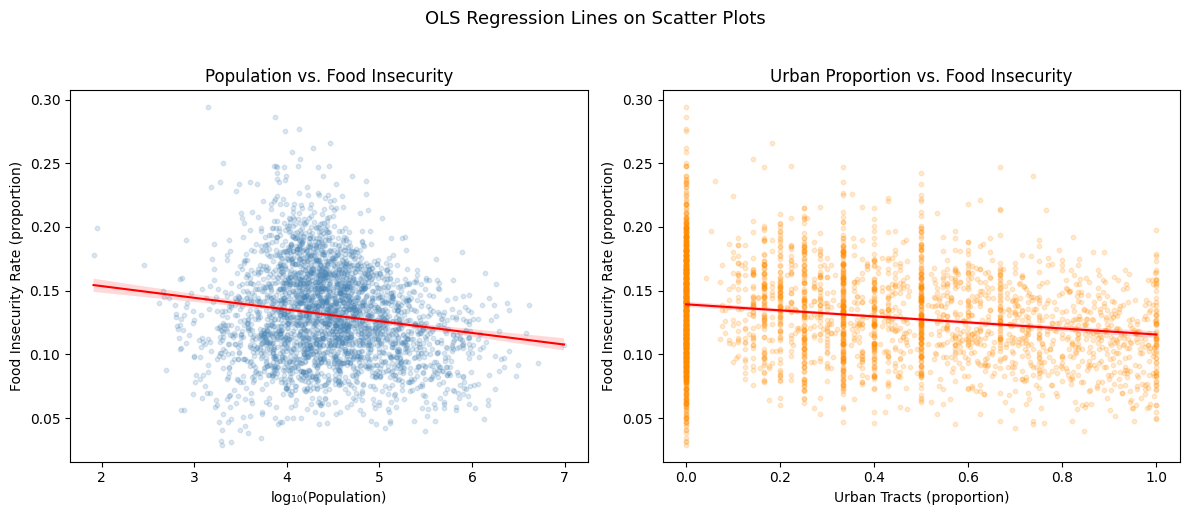

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(
    data=df_model, x='logPop', y='pctFoodInsecure', ax=axes[0],
    scatter_kws={'alpha': 0.18, 's': 10, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 1.5}
)
axes[0].set_xlabel('log₁₀(Population)')
axes[0].set_ylabel('Food Insecurity Rate (proportion)')
axes[0].set_title('Population vs. Food Insecurity')

sns.regplot(
    data=df_model, x='Urban_prop', y='pctFoodInsecure', ax=axes[1],
    scatter_kws={'alpha': 0.18, 's': 10, 'color': 'darkorange'},
    line_kws={'color': 'red', 'linewidth': 1.5}
)
axes[1].set_xlabel('Urban Tracts (proportion)')
axes[1].set_ylabel('Food Insecurity Rate (proportion)')
axes[1].set_title('Urban Proportion vs. Food Insecurity')

plt.suptitle('OLS Regression Lines on Scatter Plots', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
model = smf.ols('pctFoodInsecure ~ logPop + Urban_prop', data=df_model).fit()

sd_logPop  = df_model['logPop'].std()
sd_urbanp  = df_model['Urban_prop'].std()
sd_fi      = df_model['pctFoodInsecure'].std()

beta_pop_std = model.params['logPop']     * sd_logPop / sd_fi
beta_urb_std = model.params['Urban_prop'] * sd_urbanp / sd_fi

print(f'\nStandardized coefficients:')
print(f'  log₁₀(Pop2010): β* = {beta_pop_std:.4f}  (p = {model.pvalues["logPop"]:.3f})')
print(f'  Urban_prop:     β* = {beta_urb_std:.4f}  (p = {model.pvalues["Urban_prop"]:.4f})')


Standardized coefficients:
  log₁₀(Pop2010): β* = -0.0147  (p = 0.577)
  Urban_prop:     β* = -0.1904  (p = 0.0000)


In [6]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        pctFoodInsecure   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     66.52
Date:                Wed, 06 May 2026   Prob (F-statistic):           5.08e-29
Time:                        21:56:43   Log-Likelihood:                 5951.6
No. Observations:                3142   AIC:                        -1.190e+04
Df Residuals:                    3139   BIC:                        -1.188e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1427      0.006     23.251      0.0

## Linear Regression Model Conclusion

**Urban/rural classification is the (slightly) stronger predictor than county population count. Howevever, both population and urban flag are weak predictors.** 

| Predictor | Coefficient | Standardized β | p-value |
|---|---|---|---|
| log₁₀(Pop2010) | −0.0009 | ~−0.024 | 0.577 — not significant |
| Urban_prop | −0.0224 | ~−0.160 | < 0.001 — significant |

- Urban_prop is statistically significant. log(Pop2010) is not when both are included in the same model.
- Both predictors are negatively associated with food insecurity. 
- More urban and higher population counties tend to have lower food insecurity rates.
- Overall model fit is low (Adj. R² ≈ 0.040), indicating that these predictors alone are weak. Other varibles such as Poverty rate, unemployment, and regional factors could likely explain more variance.